Quelle évolution des prêts

In [56]:
import pandas as pd
import seaborn as sns
from datetime import datetime as dt
import matplotlib.pyplot as plt
from kiblib.utils.db import DbConn
from kiblib.utils.evolution_stats import EvolutionActivite
from kiblib.utils import charte_graphique_lgp as lgp
from kiblib.utils import lucas_sns_params
import warnings
warnings.filterwarnings("ignore")

In [57]:
maj = dt.today().strftime('%d-%m-%Y à %Hh%M' )
print(f"Dernière mise à jour le {maj}")

Dernière mise à jour le 22-08-2026 à 10h46


In [58]:
db_conn = DbConn().create_engine()

In [59]:
query = f"""SELECT YEAR(issuedate)AS 'annee_pret',COUNT(*) AS 'nb_prets'
FROM statdb.stat_issues si 
WHERE YEAR(issuedate)>={2019}
GROUP BY YEAR(issuedate)"""

In [60]:
prets_lgp = pd.read_sql(query,db_conn)
prets_lgp["Site"] = "a/ La Grand-Plage"

In [61]:
query = f"""SELECT YEAR(issuedate)AS 'annee_pret',COUNT(*) AS 'nb_prets'
FROM statdb.stat_issues si 
WHERE YEAR(issuedate)>={2019} AND branchcode = 'MED' AND location = 'MED0C'
GROUP BY YEAR(issuedate)"""

In [62]:
prets_col = pd.read_sql(query,db_conn)
prets_col["Site"] = "d/ Collectivités"

In [63]:
query = f"""SELECT YEAR(issuedate)AS 'annee_pret',COUNT(*) AS 'nb_prets'
FROM statdb.stat_issues si 
WHERE YEAR(issuedate)>={2019} AND location = 'BUS1A'
GROUP BY YEAR(issuedate)"""

In [64]:
prets_bus = pd.read_sql(query,db_conn)
prets_bus["Site"] = 'c/ Zèbre (bibliobus)'

In [65]:
query = f"""SELECT YEAR(issuedate)AS 'annee_pret',COUNT(*) AS 'nb_prets'
FROM statdb.stat_issues si 
WHERE YEAR(issuedate)>={2019} AND location != 'MED0C' AND location!= 'BUS1A'
GROUP BY YEAR(issuedate)"""

In [66]:
prets_med = pd.read_sql(query,db_conn)
prets_med["Site"] = "b/ Médiathèque"

In [67]:
list_df = [prets_lgp,prets_bus,prets_col,prets_med]
prets_all = pd.concat(list_df,names=list_df)
#prets_all

In [68]:
prets_all = prets_all[prets_all["annee_pret"]>=2019]

In [69]:
prets_all_pivot = prets_all.pivot_table(index="annee_pret",columns="Site",values="nb_prets")

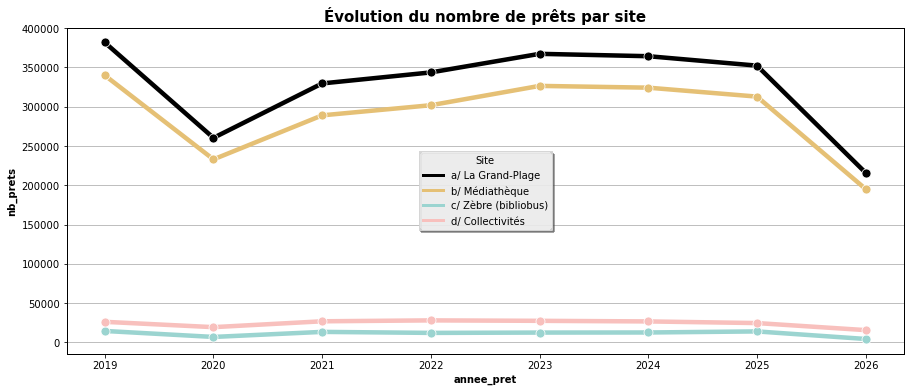

In [70]:
palette = [lgp.color5,lgp.color2,lgp.color1,lgp.color4]
linewidth=4.5
markersize=2*linewidth

ax = sns.lineplot(data=prets_all_pivot,
                  dashes=False,
                  markers=False,
                  linewidth=linewidth,
                  markersize=markersize,
                  palette=palette
                 )

ax.set_ylabel("nb_prets")
plt.grid(axis='x')
plt.title("Évolution du nombre de prêts par site")

plt.show()

In [47]:
prets_all_pivot = prets_all_pivot.T

In [48]:
for i in prets_all_pivot.index:
    print(f"prets_all_pivot[{i} -Part en %)]")
    prets_all_pivot.loc[f"{i} - Part en %"] = round(prets_all_pivot.loc[f'{i}']/prets_all_pivot.loc["a/ La Grand-Plage"]*100,0)

prets_all_pivot[a/ La Grand-Plage -Part en %)]
prets_all_pivot[b/ Médiathèque -Part en %)]
prets_all_pivot[c/ Zèbre (bibliobus) -Part en %)]
prets_all_pivot[d/ Collectivités -Part en %)]


In [49]:
prets_all_pivot

annee_pret,2019,2020,2021,2022,2023,2024,2025,2026
Site,,,,,,,,
a/ La Grand-Plage,381757.0,260294.0,329600.0,343636.0,367288.0,364269.0,352264.0,215842.0
b/ Médiathèque,339911.0,232898.0,288964.0,301863.0,326473.0,324210.0,312832.0,195159.0
c/ Zèbre (bibliobus),14479.0,6867.0,13308.0,12018.0,12427.0,12548.0,13894.0,4279.0
d/ Collectivités,26115.0,19329.0,26791.0,27954.0,27382.0,26623.0,24533.0,15555.0
a/ La Grand-Plage - Part en %,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
b/ Médiathèque - Part en %,89.0,89.0,88.0,88.0,89.0,89.0,89.0,90.0
c/ Zèbre (bibliobus) - Part en %,4.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0
d/ Collectivités - Part en %,7.0,7.0,8.0,8.0,7.0,7.0,7.0,7.0


In [50]:
query = f"""SELECT YEAR(issuedate)AS 'annee_pret',ccode ,COUNT(*) AS 'nb_prets'
FROM statdb.stat_issues si
WHERE YEAR(issuedate)>={2019}
GROUP BY YEAR(issuedate),ccode"""

In [51]:
prets_ccodes = pd.read_sql(query,db_conn)

In [52]:
prets_ccodes["ccode"].fillna('non-renseigné',inplace=True)

In [53]:
prets_ccodes.loc[prets_ccodes["ccode"].str.startswith('J'),"Secteur"] = "Jeunesse"
prets_ccodes.loc[~prets_ccodes["ccode"].str.startswith('J'),"Secteur"] = "Adulte"

In [54]:
prets_ccodes_pivot = prets_ccodes.pivot_table(index="annee_pret",columns='Secteur',values="nb_prets",aggfunc=sum)

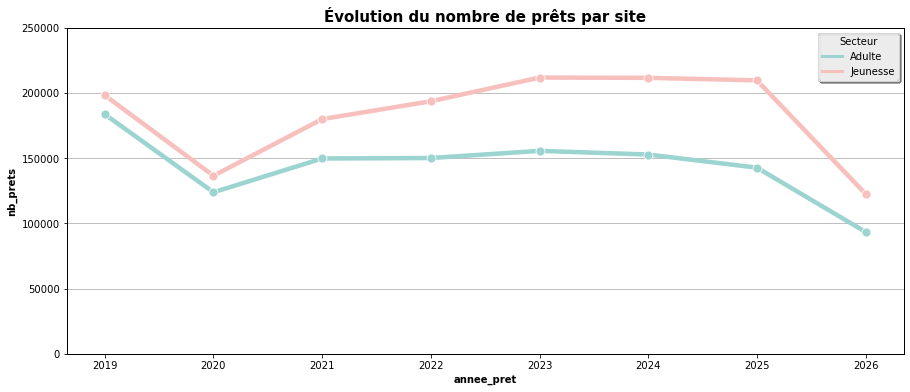

In [55]:
palette = [lgp.color1,lgp.color4]
linewidth=4.5
markersize=2*linewidth

ax = sns.lineplot(data=prets_ccodes_pivot,
                  dashes=False,
                  markers=False,
                  linewidth=linewidth,
                  markersize=markersize,
                  palette=palette
                 )

ax.set_ylabel("nb_prets")
ax.set_ylim(0,250000)
plt.grid(axis='x')
plt.title("Évolution du nombre de prêts par site")


plt.show()

In [25]:
prets_ccodes_pivot = prets_ccodes_pivot.T

In [26]:
prets_ccodes_pivot.loc["Total"] = prets_ccodes_pivot.aggregate(sum)

In [27]:
prets_ccodes_pivot

annee_pret,2019,2020,2021,2022,2023,2024,2025,2026
Secteur,,,,,,,,
Adulte,183600,123806,149705,150061,155554,152749,142660,93357
Jeunesse,198157,136488,179895,193575,211734,211520,209604,122485
Total,381757,260294,329600,343636,367288,364269,352264,215842


In [28]:
prets_ccodes_pivot.loc["Adulte - Part en %"] = round(prets_ccodes_pivot.loc["Adulte"]/prets_ccodes_pivot.loc["Total"]*100,1)
prets_ccodes_pivot.loc["Jeunesse - Part en %"] = round(prets_ccodes_pivot.loc["Jeunesse"]/prets_ccodes_pivot.loc["Total"]*100,1)

In [29]:
prets_ccodes_pivot.astype(int)

annee_pret,2019,2020,2021,2022,2023,2024,2025,2026
Secteur,,,,,,,,
Adulte,183600,123806,149705,150061,155554,152749,142660,93357
Jeunesse,198157,136488,179895,193575,211734,211520,209604,122485
Total,381757,260294,329600,343636,367288,364269,352264,215842
Adulte - Part en %,48,47,45,43,42,41,40,43
Jeunesse - Part en %,51,52,54,56,57,58,59,56
